# The New Memory Hierarchy — figures with provenance

This notebook regenerates the memory-hierarchy figures from the **committed profiles** in this repo, rather than drawing them by hand. Every number plotted here comes from a `hwprofile/v1` or `modelprofile/v1` YAML file; measured values are labeled measured, and unmeasured values render as *unmeasured* rather than being invented — the same [provenance rule](../GOVERNANCE.md#results-integrity) as everything else in the project.

Companion prose: [docs/memory_hierarchy.md](../docs/memory_hierarchy.md). Setup:

```bash
pip install -e ".[notebook]"
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
HW_DIR = REPO / "hardware_profiles"
MODEL_DIR = REPO / "model_profiles"

NAVY = "#0a0f1e"
SLATE = "#5a6b8c"
CORAL = "#ff5a4e"
INK = "#e8ecf4"

profiles = {
    p.stem: yaml.safe_load(p.read_text())
    for p in sorted(HW_DIR.glob("*.yaml"))
}
list(profiles)

Matplotlib is building the font cache; this may take a moment.


['apple_m5_max_137gb_detected',
 'gb10_128gb',
 'm5_max_128gb',
 'rtx6000_96gb_64ram']

## Each machine's hierarchy, from its committed profile

A `hwprofile/v1` file has no fixed `vram/ram/ssd` fields — it is a graph of nodes and links. Here we pull out the memory and storage nodes per machine and order them fast-to-slow. Bandwidths come from the profile's `measured` fields; where the profile says `null`, the chart says *unmeasured*.

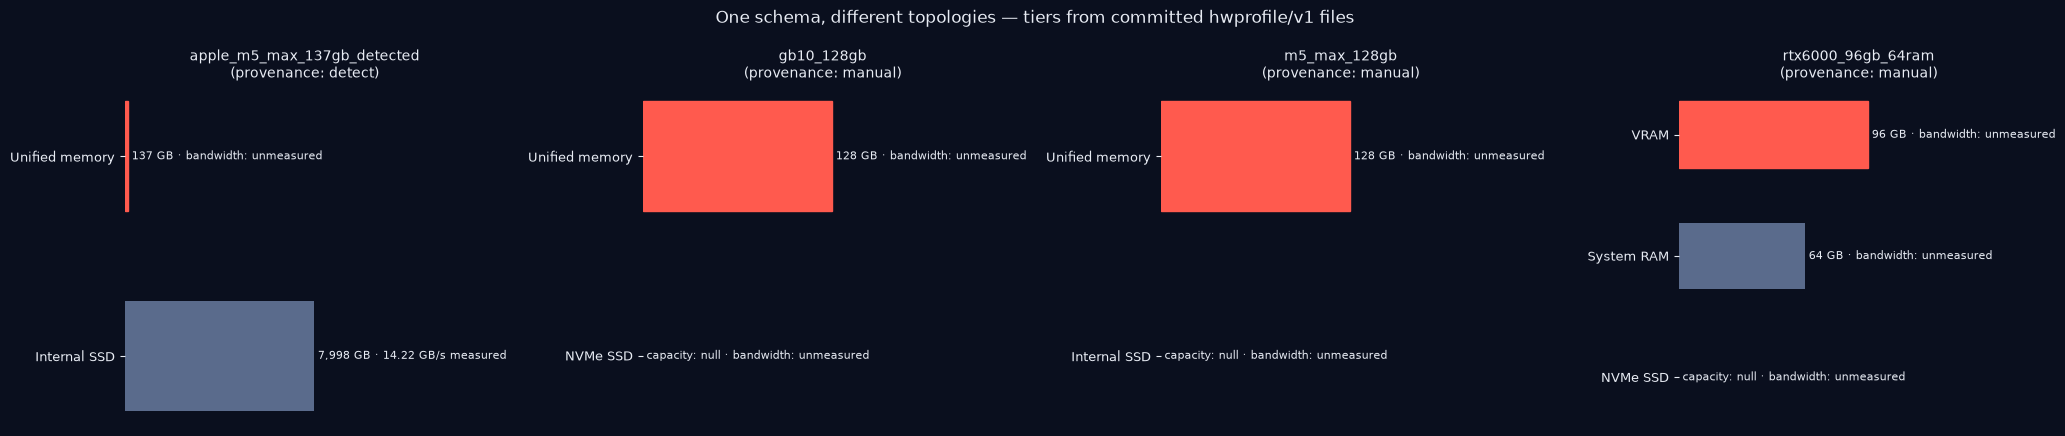

In [2]:
# Fast-to-slow ordering of node classes across all machine shapes.
TIER_ORDER = ["device_local", "unified", "system", "nvme", "internal_ssd"]
TIER_LABEL = {
    "device_local": "VRAM",
    "unified": "Unified memory",
    "system": "System RAM",
    "nvme": "NVMe SSD",
    "internal_ssd": "Internal SSD",
}


def tiers_of(profile: dict) -> list[dict]:
    """Extract memory/storage tiers from a hwprofile resource graph, fast to slow."""
    rows = []
    for node in profile["nodes"]:
        if node["kind"] not in ("memory", "storage"):
            continue
        measured = node.get("measured") or {}
        bw = measured.get("seq_read_gbps")
        if bw is None:
            bw = (node.get("bandwidth_gbps") or {}).get("measured")
        rows.append(
            {
                "tier": TIER_LABEL.get(node["class"], node["class"]),
                "class": node["class"],
                "capacity_gb": node.get("capacity_gb"),
                "bandwidth_gbps": bw,  # None = unmeasured, never guessed
            }
        )
    return sorted(rows, key=lambda r: TIER_ORDER.index(r["class"]))


fig, axes = plt.subplots(1, len(profiles), figsize=(5.2 * len(profiles), 4.4))
fig.patch.set_facecolor(NAVY)

for ax, (pid, profile) in zip(axes, profiles.items()):
    rows = tiers_of(profile)
    names = [r["tier"] for r in rows][::-1]
    caps = [r["capacity_gb"] or 0 for r in rows][::-1]
    provenance = profile["provenance"]["method"]

    bars = ax.barh(names, caps, color=SLATE, height=0.55)
    bars[-1].set_color(CORAL)  # fastest tier gets the accent
    for bar, row in zip(bars, rows[::-1]):
        cap = row["capacity_gb"]
        bw = row["bandwidth_gbps"]
        cap_txt = f"{cap:,.0f} GB" if cap else "capacity: null"
        bw_txt = f"{bw:.2f} GB/s measured" if bw is not None else "bandwidth: unmeasured"
        ax.text(
            bar.get_width() + max(caps) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{cap_txt} · {bw_txt}",
            va="center", fontsize=8, color=INK,
        )

    ax.set_title(f"{pid}\n(provenance: {provenance})", fontsize=10, color=INK)
    ax.set_facecolor(NAVY)
    ax.set_xlim(0, max(caps) * 1.9 if any(caps) else 1)
    ax.tick_params(colors=INK, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])

fig.suptitle(
    "One schema, different topologies — tiers from committed hwprofile/v1 files",
    color=INK, fontsize=12,
)
fig.tight_layout()
plt.show()

## Old pyramid vs new pyramid, to scale

The classic hierarchy's levels are textbook orders of magnitude (illustrative, labeled as such). The AI hierarchy's levels below come from the committed profiles where we have them. Log scale — that is the point.

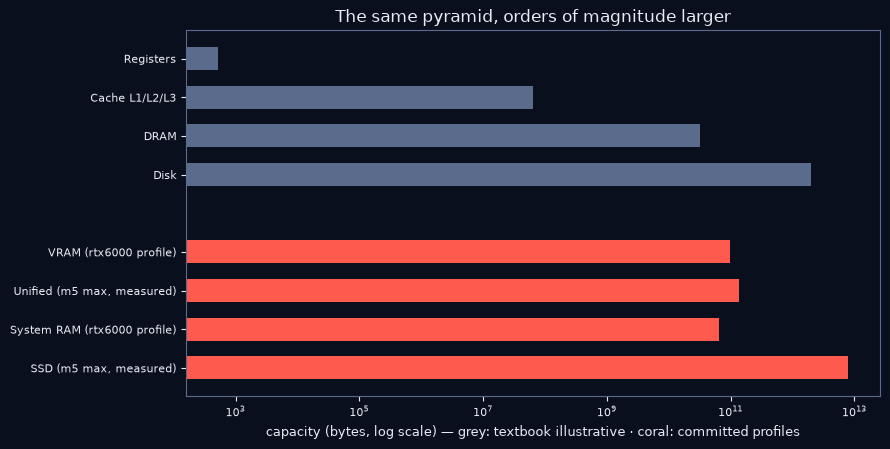

In [3]:
# Classic levels: illustrative textbook magnitudes (bytes), labeled as such.
classic = [
    ("Registers", 512),
    ("Cache L1/L2/L3", 64e6),
    ("DRAM", 32e9),
    ("Disk", 2e12),
]

# AI levels: capacities from committed profiles (bytes, decimal GB).
m5 = profiles["apple_m5_max_137gb_detected"]
rtx = profiles["rtx6000_96gb_64ram"]
by_class = lambda p, cls: next(n for n in p["nodes"] if n.get("class") == cls)

ai = [
    ("VRAM (rtx6000 profile)", by_class(rtx, "device_local")["capacity_gb"] * 1e9),
    ("Unified (m5 max, measured)", by_class(m5, "unified")["capacity_gb"] * 1e9),
    ("System RAM (rtx6000 profile)", by_class(rtx, "system")["capacity_gb"] * 1e9),
    ("SSD (m5 max, measured)", by_class(m5, "internal_ssd")["capacity_gb"] * 1e9),
]

fig, ax = plt.subplots(figsize=(9, 4.6))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

y_classic = range(len(classic))
y_ai = range(len(classic) + 1, len(classic) + 1 + len(ai))
ax.barh(list(y_classic), [b for _, b in classic], color=SLATE, height=0.6)
ax.barh(list(y_ai), [b for _, b in ai], color=CORAL, height=0.6)

ax.set_yticks(list(y_classic) + list(y_ai))
ax.set_yticklabels(
    [n for n, _ in classic] + [n for n, _ in ai], fontsize=9, color=INK
)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("capacity (bytes, log scale) — grey: textbook illustrative · coral: committed profiles", fontsize=9, color=INK)
ax.tick_params(colors=INK, labelsize=8)
for spine in ax.spines.values():
    spine.set_color(SLATE)
ax.set_title("The same pyramid, orders of magnitude larger", color=INK, fontsize=12)
fig.tight_layout()
plt.show()

## The miss penalty: worst-case streaming math

The classic hierarchy's miss penalty is nanoseconds; the new one stalls the decode loop for milliseconds per expert miss. This is the worked worst case from [architecture.md](../docs/architecture.md), computed from the committed GLM-5.2 Q2 profile — measured per-expert sizes, upstream-claimed activation counts, and the one measured SSD bandwidth we have.

In [4]:
glm = yaml.safe_load((MODEL_DIR / "glm_5_2" / "q2_routed.yaml").read_text())

per_expert_gb = glm["memory_model"]["per_expert_gb"]["q2_routed"]          # measured
routed_total_gb = glm["memory_model"]["measurement"]["routed_experts_gb"]["q2_routed"]  # measured
experts_total = glm["architecture"]["experts"]["routed_total"]             # upstream claim
active_per_token = glm["architecture"]["experts"]["active_per_token"]      # upstream claim

moe_layers = round(routed_total_gb / (per_expert_gb * experts_total))
worst_case_gb_per_token = active_per_token * moe_layers * per_expert_gb

m5_ssd_gbps = by_class(m5, "internal_ssd")["measured"]["seq_read_gbps"]    # measured

print(f"per (expert, layer) slice        {per_expert_gb} GB        (measured, GGUF headers)")
print(f"routed experts total             {routed_total_gb} GB      (measured)")
print(f"MoE layers                       ~{moe_layers}")
print(f"active experts per token         {active_per_token}               (upstream claim)")
print()
print(f"worst case (every activation misses to storage):")
print(f"  {active_per_token} x {moe_layers} x {per_expert_gb} GB  ~=  {worst_case_gb_per_token:.2f} GB per token")
print()
print(f"on the M5 Max SSD ({m5_ssd_gbps} GB/s, measured):"
      f"  ~{worst_case_gb_per_token / m5_ssd_gbps:.2f} s per token"
      f"  (~{m5_ssd_gbps / worst_case_gb_per_token:.1f} tokens/s)")
print()
print("Unusable — which is the point. How far real expert locality moves you")
print("off this worst case is the empirical question the benchmarks exist to answer.")

per (expert, layer) slice        0.011 GB        (measured, GGUF headers)
routed experts total             222.87 GB      (measured)
MoE layers                       ~79
active experts per token         8               (upstream claim)

worst case (every activation misses to storage):
  8 x 79 x 0.011 GB  ~=  6.95 GB per token

on the M5 Max SSD (14.22 GB/s, measured):  ~0.49 s per token  (~2.0 tokens/s)

Unusable — which is the point. How far real expert locality moves you
off this worst case is the empirical question the benchmarks exist to answer.
